# CD-A: L0 vs L1 penalty (with and without weak-faithfulness)

Compares four families of algorithm on the same ER / Gaussian data:

- **L0 plain** — `coordinate0.dag_coordinate_descent_l0` (via the
  weakfaith wrapper with `faithfulness_tau=0`, byte-equivalent under
  the same seed).
- **L0 + weakfaith** — `cd_A_weakfaith.dag_coordinate_descent_l0_weakfaith`
  with pcorr screening at $\tau = 0.05$.
- **L1 plain** — `cd_A_l1.dag_coordinate_descent_l1` with `faithfulness_tau=0`.
- **L1 + weakfaith** — same function with pcorr screening at $\tau = 0.05$.

L1 is scanned over `lambda_l1 ∈ {0.05, 0.1, 0.2}` because the
appropriate value depends on typical edge magnitude; L0 is fixed at
`lambda_l0 = 0.2` (the canonical setting in prior benchmarks).

Metrics: SHD, CPDAG-SHD, MEC match, runtime, actual steps when
early-stopped, and mask keep ratio for the screened variants.


In [ ]:
# 1) Environment and imports
import os
import sys
import time
import warnings
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

repo_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..'))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

from MEC import is_in_markov_equiv_class, get_skeleton, find_v_structures
from synthetic_dataset import SyntheticDataset
from coordinate_descent.cd_A_weakfaith import (
    dag_coordinate_descent_l0_weakfaith as cd_l0_fit,
    _build_faithfulness_mask,
    _screen_forbidden,
)
from coordinate_descent.cd_A_l1 import dag_coordinate_descent_l1 as cd_l1_fit

try:
    _tb = os.path.join(repo_root, 'toolbox')
    if _tb not in sys.path:
        sys.path.append(_tb)
    from cdt.metrics import SHD_CPDAG as _SHD_CPDAG
    HAS_CPDAG_SHD = True
except Exception as _e:
    _SHD_CPDAG = None
    HAS_CPDAG_SHD = False
    print('CPDAG-SHD backend unavailable (fallback):', _e)

# Silence sklearn graphical_lasso convergence chatter during the run.
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)

print('Python   :', sys.version.split()[0])
print('Repo root:', repo_root)
print('cd_A L0 (weakfaith) : OK')
print('cd_A L1             : OK')


In [3]:
# 2) Helpers
def weight_to_binary_adj(W: np.ndarray, threshold: float = 0.05) -> np.ndarray:
    G = (np.abs(W) > threshold).astype(int)
    np.fill_diagonal(G, 0)
    return G


def cpdag_shd_score(G_true, G_est):
    if HAS_CPDAG_SHD:
        try:
            return float(_SHD_CPDAG(G_true.astype(int), G_est.astype(int)))
        except Exception:
            pass
    skel_true = get_skeleton(G_true)
    skel_est = get_skeleton(G_est)
    skel_diff = int(np.sum(np.abs(skel_true - skel_est)) // 2)
    v_diff = len(find_v_structures(G_true).symmetric_difference(find_v_structures(G_est)))
    return float(skel_diff + v_diff)


def shd_score(G_true, G_est):
    G_true = np.asarray(G_true, dtype=int)
    G_est = np.asarray(G_est, dtype=int)
    d, dist = G_true.shape[0], 0
    for i in range(d):
        for j in range(i + 1, d):
            if G_true[i, j] != G_est[i, j] or G_true[j, i] != G_est[j, i]:
                dist += 1
    return float(dist)


def make_row(d, n, trial_id, seed, alg, runtime_sec, G_true, G_est,
             actual_steps=None, mask_keep_ratio=None, extra=None):
    row = {
        'd': d, 'n_samples': n, 'trial_id': trial_id, 'seed': seed,
        'algorithm': alg,
        'mec_match': int(is_in_markov_equiv_class(G_true, G_est)),
        'shd': shd_score(G_true, G_est),
        'cpdag_shd': cpdag_shd_score(G_true, G_est),
        'n_edges_true': int(G_true.sum()),
        'n_edges_est': int(G_est.sum()),
        'runtime_sec': float(runtime_sec),
    }
    if actual_steps is not None:
        row['actual_steps'] = int(actual_steps)
    if mask_keep_ratio is not None:
        row['mask_keep_ratio'] = float(mask_keep_ratio)
    if extra:
        row.update(extra)
    return row


def summarize(df):
    if len(df) == 0:
        return pd.DataFrame()
    agg = dict(
        mec_match_mean=('mec_match', 'mean'),
        shd_mean=('shd', 'mean'),
        cpdag_shd_mean=('cpdag_shd', 'mean'),
        runtime_sec_mean=('runtime_sec', 'mean'),
        trials=('trial_id', 'count'),
    )
    if 'actual_steps' in df.columns:
        agg['actual_steps_mean'] = ('actual_steps', 'mean')
    if 'mask_keep_ratio' in df.columns:
        agg['mask_keep_ratio_mean'] = ('mask_keep_ratio', 'mean')
    return df.groupby(['algorithm', 'd', 'n_samples'], as_index=False).agg(**agg)


def iter_trials(cfg):
    rng = np.random.default_rng(cfg['seed'])
    for d in cfg['d_list']:
        for n in cfg['n_list']:
            seeds = rng.integers(0, 10**9, size=cfg['trials'])
            for trial_idx, seed in enumerate(seeds, start=1):
                ds = SyntheticDataset(
                    n=n, d=d, graph_type='ER', degree=cfg['degree'],
                    noise_type=cfg['noise_type'], B_scale=cfg['b_scale'],
                    seed=int(seed),
                )
                X = ds.X
                S = X.T @ X / X.shape[0]
                G_true = weight_to_binary_adj(ds.B, threshold=0.0)
                yield d, n, trial_idx, int(seed), X, S, G_true


def _mask_key(screening, combine, tau):
    names = [screening] if isinstance(screening, str) else list(screening)
    return (tuple(sorted(names)), combine, float(tau))


def run_variants(variants, cfg, verbose=True):
    """Run mixed L0/L1 variants (each may also enable weakfaith via tau>0).

    Each variant dict carries:
      - label   : str
      - penalty : 'l0' | 'l1'
      - lambda_ : float
      - faithfulness_tau : float (0 disables screening)
      - screening, sampling_mode, combine : weakfaith params (used when tau>0)
    """
    rows, skips = [], []
    for d, n, trial_id, seed, X, S, G_true in iter_trials(cfg):
        keep_cache = {}
        for v in variants:
            tau = v.get('faithfulness_tau', 0.0)
            if tau <= 0.0:
                continue
            comb = v.get('combine', 'union')
            key = _mask_key(v['screening'], comb, tau)
            if key in keep_cache:
                continue
            try:
                _, M = _build_faithfulness_mask(
                    S, tau, v['screening'],
                    glasso_alpha=cfg.get('glasso_alpha', 0.01),
                    combine=comb,
                )
                keep_cache[key] = M / (d * (d - 1))
            except ValueError:
                keep_cache[key] = None

        for v in variants:
            label = v['label']
            tau = v.get('faithfulness_tau', 0.0)
            comb = v.get('combine', 'union')
            sampling = v.get('sampling_mode', 'preserve')
            screening = v.get('screening', 'corr')
            keep_ratio = 1.0
            if tau > 0.0:
                keep_ratio = keep_cache.get(_mask_key(screening, comb, tau))
                if keep_ratio is None:
                    skips.append(dict(algorithm=label, d=d, n_samples=n,
                                      trial_id=trial_id, reason='mask empty'))
                    continue

            try:
                t0 = time.perf_counter()
                common = dict(
                    S=S, T=cfg['T'], seed=seed,
                    threshold=cfg['threshold'],
                    early_stop=cfg['early_stop'],
                    check_every=cfg['es_check_every'],
                    tol=cfg['es_tol'], patience=cfg['es_patience'],
                    min_steps=cfg['es_min_steps'],
                    return_history=cfg['early_stop'],
                    faithfulness_tau=tau,
                    sampling_mode=sampling,
                    screening=screening,
                    glasso_alpha=cfg.get('glasso_alpha', 0.01),
                    combine=comb,
                )
                if v['penalty'] == 'l0':
                    result = cd_l0_fit(lambda_l0=v['lambda_'], **common)
                elif v['penalty'] == 'l1':
                    result = cd_l1_fit(lambda_l1=v['lambda_'], **common)
                else:
                    raise ValueError(f"unknown penalty {v['penalty']!r}")
                rt = time.perf_counter() - t0

                if cfg['early_stop']:
                    _, G_est, _, history = result
                    actual_steps = len(history)
                else:
                    _, G_est, _ = result
                    actual_steps = None

                row = make_row(
                    d, n, trial_id, seed, label, rt, G_true, G_est,
                    actual_steps=actual_steps, mask_keep_ratio=keep_ratio,
                    extra=dict(penalty=v['penalty'], lambda_val=v['lambda_'],
                               tau=tau, has_wf=int(tau > 0)),
                )
                rows.append(row)
                if verbose:
                    s_str = f' steps={actual_steps}' if actual_steps is not None else ''
                    k_str = f' keep={keep_ratio:.2f}' if tau > 0 else ''
                    print(
                        f'[{label:34s}] d={d} n={n} trial={trial_id} '
                        f'mec={row["mec_match"]} shd={row["shd"]:.0f} '
                        f'cshd={row["cpdag_shd"]:.0f} rt={rt:.2f}s{s_str}{k_str}'
                    )
            except Exception as e:
                skips.append(dict(algorithm=label, d=d, n_samples=n,
                                  trial_id=trial_id, reason=str(e)))
                if verbose:
                    print(f'[SKIP] {label} d={d} n={n} trial={trial_id}: {e}')
    return pd.DataFrame(rows), skips


print('Helpers ready.')


Helpers ready.


In [4]:
# 3) Config and variants
CFG = {
    'trials': 20,
    'seed': 42,
    'd_list': [30, 40, 50],
    'n_list': [20000],
    'degree': 2.0,
    'noise_type': 'gaussian_nv',
    'b_scale': 1.0,
    'threshold': 0.05,
    'T': 100000,
    'out_dir': os.path.join(repo_root, 'experiments', 'results'),
    'tag': 'er_cd_A_l0_vs_l1_benchmark',
    # Early stopping
    'early_stop': True,
    'es_check_every': None,
    'es_tol': 1e-4,
    'es_patience': 10,
    'es_min_steps': None,
    # Graphical Lasso (only relevant if 'glasso' is in screening)
    'glasso_alpha': 0.01,
}
os.makedirs(CFG['out_dir'], exist_ok=True)

# Canonical weakfaith: pcorr at tau=0.05 (best in the prior benchmark).
WF = dict(
    faithfulness_tau=0.05,
    screening=['pcorr'],
    sampling_mode='preserve',
    combine='union',
)

LAMBDA_L0 = 0.2
L1_LAMBDAS = [0.05, 0.1, 0.2]

VARIANTS = [
    # L0
    dict(label='cd_A_l0',                   penalty='l0', lambda_=LAMBDA_L0,
         faithfulness_tau=0.0),
    dict(label='cd_A_l0_weakfaith_pcorr',   penalty='l0', lambda_=LAMBDA_L0,
         **WF),
]
# L1 plain at several lambdas
for lam in L1_LAMBDAS:
    VARIANTS.append(dict(
        label=f'cd_A_l1_lam{lam}', penalty='l1', lambda_=lam,
        faithfulness_tau=0.0,
    ))
# L1 + weakfaith at the same lambdas
for lam in L1_LAMBDAS:
    VARIANTS.append(dict(
        label=f'cd_A_l1_weakfaith_pcorr_lam{lam}', penalty='l1', lambda_=lam,
        **WF,
    ))

print('Config ready.')
print(f"  d_list      : {CFG['d_list']}")
print(f"  n_list      : {CFG['n_list']}")
print(f"  trials      : {CFG['trials']}")
print(f"  T (budget)  : {CFG['T']}")
print(f"  WF screening: {WF['screening']}, tau={WF['faithfulness_tau']}")
print(f"  lambda_l0   : {LAMBDA_L0}")
print(f"  lambda_l1   : {L1_LAMBDAS}")
print(f"  variants    : {len(VARIANTS)}")
for v in VARIANTS:
    print(f"    - {v['label']}")


Config ready.
  d_list      : [30, 40, 50]
  n_list      : [20000]
  trials      : 20
  T (budget)  : 100000
  WF screening: ['pcorr'], tau=0.05
  lambda_l0   : 0.2
  lambda_l1   : [0.05, 0.1, 0.2]
  variants    : 8
    - cd_A_l0
    - cd_A_l0_weakfaith_pcorr
    - cd_A_l1_lam0.05
    - cd_A_l1_lam0.1
    - cd_A_l1_lam0.2
    - cd_A_l1_weakfaith_pcorr_lam0.05
    - cd_A_l1_weakfaith_pcorr_lam0.1
    - cd_A_l1_weakfaith_pcorr_lam0.2


In [5]:
# 4) Run all variants
df_trials, skip_logs = run_variants(VARIANTS, CFG)
df_summary = summarize(df_trials)

print('\nPer-(algorithm, d, n) summary:')
display(df_summary)


[cd_A_l0                           ] d=30 n=20000 trial=1 mec=0 shd=14 cshd=16 rt=9.00s steps=21390
[cd_A_l0_weakfaith_pcorr           ] d=30 n=20000 trial=1 mec=1 shd=1 cshd=0 rt=5.50s steps=16275 keep=0.09
[cd_A_l1_lam0.05                   ] d=30 n=20000 trial=1 mec=0 shd=20 cshd=29 rt=8.12s steps=21390
[cd_A_l1_lam0.1                    ] d=30 n=20000 trial=1 mec=0 shd=11 cshd=14 rt=8.53s steps=21390
[cd_A_l1_lam0.2                    ] d=30 n=20000 trial=1 mec=0 shd=11 cshd=14 rt=8.75s steps=21390
[cd_A_l1_weakfaith_pcorr_lam0.05   ] d=30 n=20000 trial=1 mec=1 shd=1 cshd=0 rt=6.07s steps=16275 keep=0.09
[cd_A_l1_weakfaith_pcorr_lam0.1    ] d=30 n=20000 trial=1 mec=1 shd=1 cshd=0 rt=5.46s steps=16275 keep=0.09
[cd_A_l1_weakfaith_pcorr_lam0.2    ] d=30 n=20000 trial=1 mec=1 shd=1 cshd=0 rt=5.70s steps=16275 keep=0.09
[cd_A_l0                           ] d=30 n=20000 trial=2 mec=0 shd=15 cshd=24 rt=8.83s steps=23715
[cd_A_l0_weakfaith_pcorr           ] d=30 n=20000 trial=2 mec=0 shd=

,algorithm,d,n_samples,mec_match_mean,shd_mean,cpdag_shd_mean,runtime_sec_mean,trials,actual_steps_mean,mask_keep_ratio_mean
0,cd_A_l0,30,20000,0.00,23.45,44.75,13.377768,20,36990.75,1.000000
1,cd_A_l0,40,20000,0.00,29.20,51.05,30.432152,20,63056.00,1.000000
2,cd_A_l0,50,20000,0.00,39.20,73.90,65.373315,20,92193.75,1.000000
3,cd_A_l0_weakfaith_pcorr,30,20000,0.35,4.25,5.45,10.632367,20,31527.00,0.112989
4,cd_A_l0_weakfaith_pcorr,40,20000,0.20,6.65,8.70,23.669580,20,49856.00,0.077372
5,cd_A_l0_weakfaith_pcorr,50,20000,0.10,7.80,12.60,56.556369,20,81218.75,0.063633
6,cd_A_l1_lam0.05,30,20000,0.00,26.00,52.20,15.958061,20,38734.50,1.000000
7,cd_A_l1_lam0.05,40,20000,0.00,42.90,87.35,39.438549,20,68380.00,1.000000
8,cd_A_l1_lam0.05,50,20000,0.00,51.70,128.45,81.325646,20,94607.50,1.000000
9,cd_A_l1_lam0.1,30,20000,0.00,26.40,56.55,14.910321,20,37409.25,1.000000


In [6]:
# 5) Save results
if len(df_trials) == 0:
    print('WARNING: no results collected.')
else:
    ts = datetime.now().strftime('%Y%m%d_%H%M%S')
    p_trials  = os.path.join(CFG['out_dir'], f"{CFG['tag']}_trials_{ts}.csv")
    p_summary = os.path.join(CFG['out_dir'], f"{CFG['tag']}_summary_{ts}.csv")
    p_trials_latest  = os.path.join(CFG['out_dir'], f"{CFG['tag']}_trials.csv")
    p_summary_latest = os.path.join(CFG['out_dir'], f"{CFG['tag']}_summary.csv")
    df_trials.to_csv(p_trials, index=False)
    df_summary.to_csv(p_summary, index=False)
    df_trials.to_csv(p_trials_latest, index=False)
    df_summary.to_csv(p_summary_latest, index=False)
    print(f'Trials  : {p_trials}')
    print(f'Summary : {p_summary}')
    print(f'Rows: {len(df_trials)}  |  Skips: {len(skip_logs)}')


Trials  : c:\Users\super\DAG\experiments\results\er_cd_A_l0_vs_l1_benchmark_trials_20260425_233940.csv
Summary : c:\Users\super\DAG\experiments\results\er_cd_A_l0_vs_l1_benchmark_summary_20260425_233940.csv
Rows: 480  |  Skips: 0


In [7]:
# 6) Overall comparison (aggregated across d)
if len(df_trials) == 0:
    print('Run cell 4 first.')
else:
    agg_dict = dict(
        mec_match_mean=('mec_match', 'mean'),
        shd_mean=('shd', 'mean'),
        cpdag_shd_mean=('cpdag_shd', 'mean'),
        runtime_sec_mean=('runtime_sec', 'mean'),
        trials=('trial_id', 'count'),
    )
    if 'actual_steps' in df_trials.columns:
        agg_dict['actual_steps_mean'] = ('actual_steps', 'mean')
    if 'mask_keep_ratio' in df_trials.columns:
        agg_dict['mask_keep_mean'] = ('mask_keep_ratio', 'mean')
    order = [v['label'] for v in VARIANTS]
    df_overall = df_trials.groupby('algorithm', as_index=False).agg(**agg_dict)
    df_overall['algorithm'] = pd.Categorical(df_overall['algorithm'], order, ordered=True)
    df_overall = df_overall.sort_values('algorithm').reset_index(drop=True)
    display(df_overall)


,algorithm,mec_match_mean,shd_mean,cpdag_shd_mean,runtime_sec_mean,trials,actual_steps_mean,mask_keep_mean
0,cd_A_l0,0.000000,30.616667,56.566667,36.394411,60,64080.166667,1.000000
1,cd_A_l0_weakfaith_pcorr,0.216667,6.233333,8.916667,30.286105,60,54200.583333,0.084664
2,cd_A_l1_lam0.05,0.000000,40.200000,89.333333,45.574085,60,67240.666667,1.000000
3,cd_A_l1_lam0.1,0.000000,38.766667,79.933333,42.370690,60,67105.666667,1.000000
4,cd_A_l1_lam0.2,0.000000,36.650000,76.333333,41.305960,60,65910.166667,1.000000
5,cd_A_l1_weakfaith_pcorr_lam0.05,0.316667,6.233333,7.550000,30.902258,60,54610.750000,0.084664
6,cd_A_l1_weakfaith_pcorr_lam0.1,0.300000,6.566667,7.833333,31.589164,60,55676.833333,0.084664
7,cd_A_l1_weakfaith_pcorr_lam0.2,0.266667,6.950000,8.050000,32.885833,60,57641.916667,0.084664


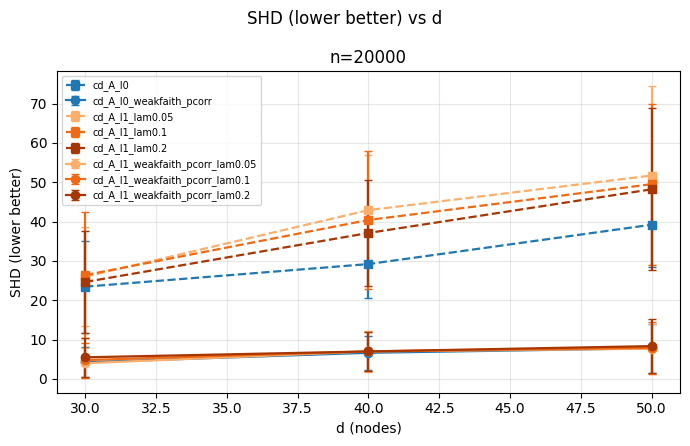

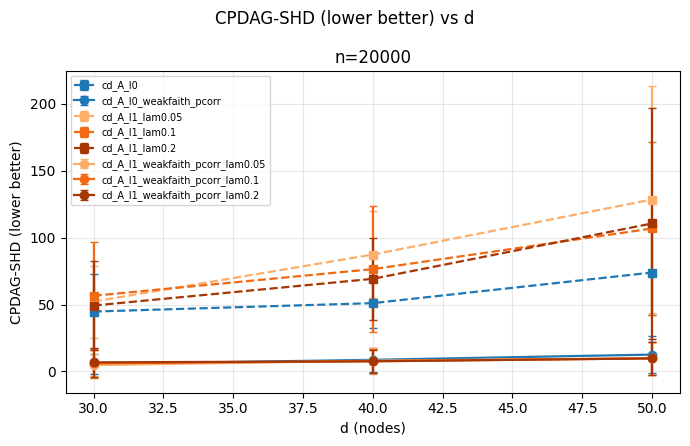

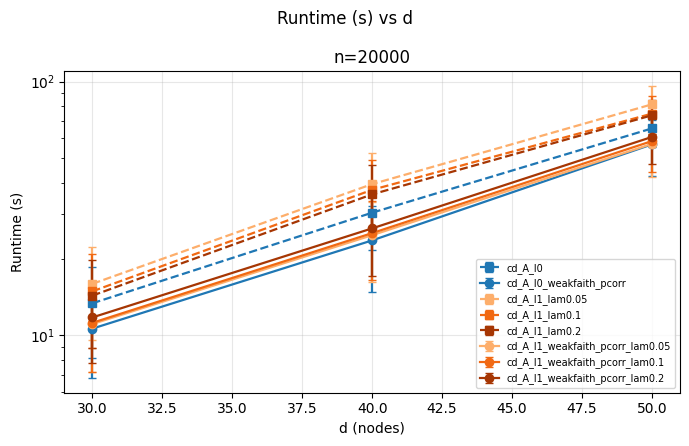

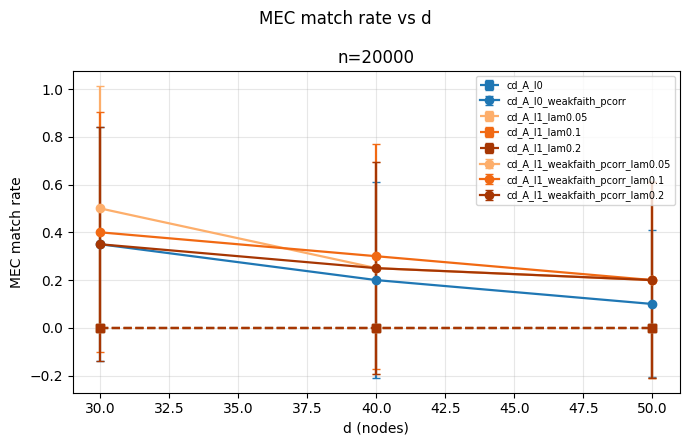

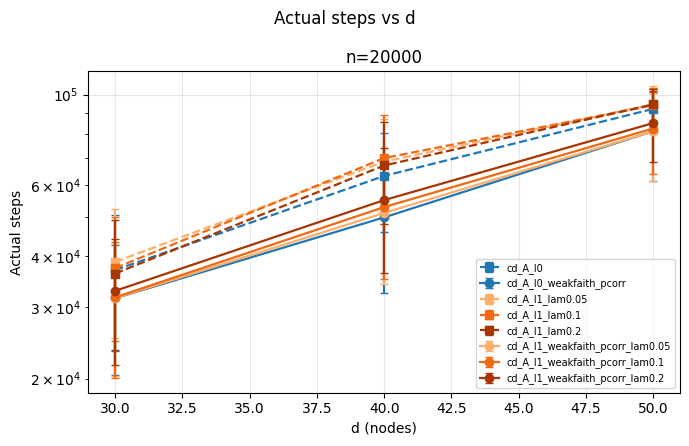

In [8]:
# 7) Plots: metrics vs d
# Color-codes: blue family = L0, orange family = L1 (deeper = larger lambda).
# Solid line = weakfaith on, dashed = no screening.
if len(df_trials) == 0:
    print('Run cell 4 first.')
else:
    algs = [v['label'] for v in VARIANTS]
    L1_COLORS = ['#fdae6b', '#f16913', '#a63603']  # by lambda index

    def alg_style(label):
        is_l1 = 'cd_A_l1' in label
        is_wf = 'weakfaith' in label
        if is_l1:
            color = '#f16913'
            for k, lam in enumerate(L1_LAMBDAS):
                if f'lam{lam}' in label:
                    color = L1_COLORS[k]
                    break
        else:
            color = '#1f77b4'
        ls = '-' if is_wf else '--'
        marker = 'o' if is_wf else 's'
        return color, ls, marker

    n_vals = sorted(df_trials['n_samples'].unique())
    metric_specs = [
        ('shd', 'SHD (lower better)', False),
        ('cpdag_shd', 'CPDAG-SHD (lower better)', False),
        ('runtime_sec', 'Runtime (s)', True),
        ('mec_match', 'MEC match rate', False),
    ]
    if 'actual_steps' in df_trials.columns:
        metric_specs.append(('actual_steps', 'Actual steps', True))

    for metric, ylabel, log_y in metric_specs:
        fig, axes = plt.subplots(
            1, len(n_vals), figsize=(7 * len(n_vals), 4.5),
            sharey=True, squeeze=False,
        )
        for ci, n in enumerate(n_vals):
            ax = axes[0][ci]
            sub = df_trials[df_trials['n_samples'] == n]
            agg = sub.groupby(['d', 'algorithm'])[metric].agg(['mean', 'std']).reset_index()
            for alg in algs:
                vals = agg[agg['algorithm'] == alg].sort_values('d')
                if len(vals) == 0:
                    continue
                color, ls, marker = alg_style(alg)
                ax.errorbar(
                    vals['d'], vals['mean'], yerr=vals['std'].fillna(0),
                    marker=marker, capsize=3, label=alg,
                    color=color, ls=ls, lw=1.6, ms=6,
                )
            ax.set_xlabel('d (nodes)')
            if ci == 0:
                ax.set_ylabel(ylabel)
            if log_y:
                ax.set_yscale('log')
            ax.set_title(f'n={n}')
            ax.grid(True, alpha=0.3)
            ax.legend(fontsize=7, loc='best')
        fig.suptitle(f'{ylabel} vs d', fontsize=12)
        plt.tight_layout()
        plt.show()


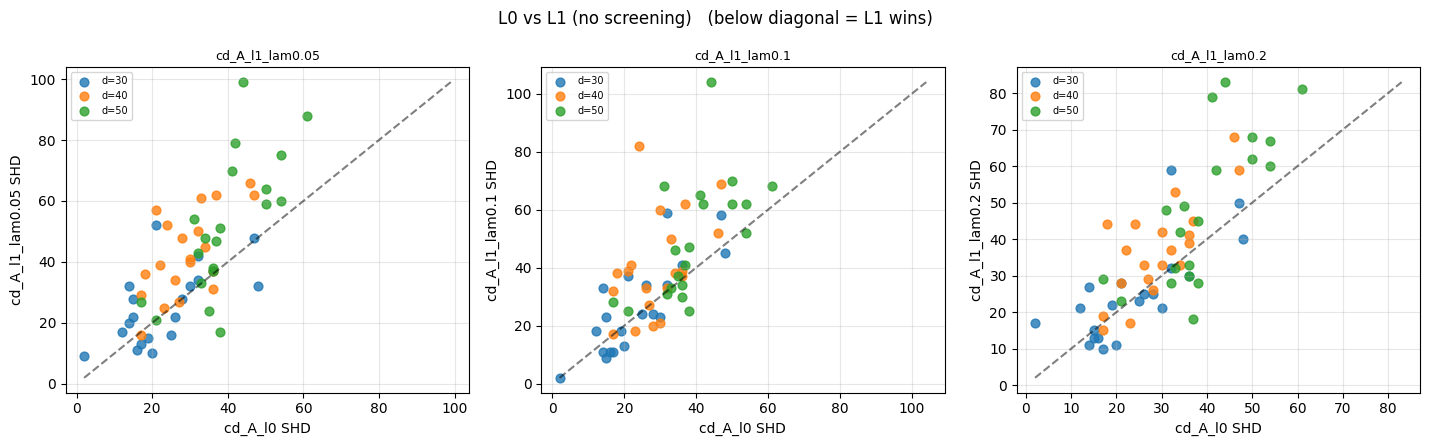

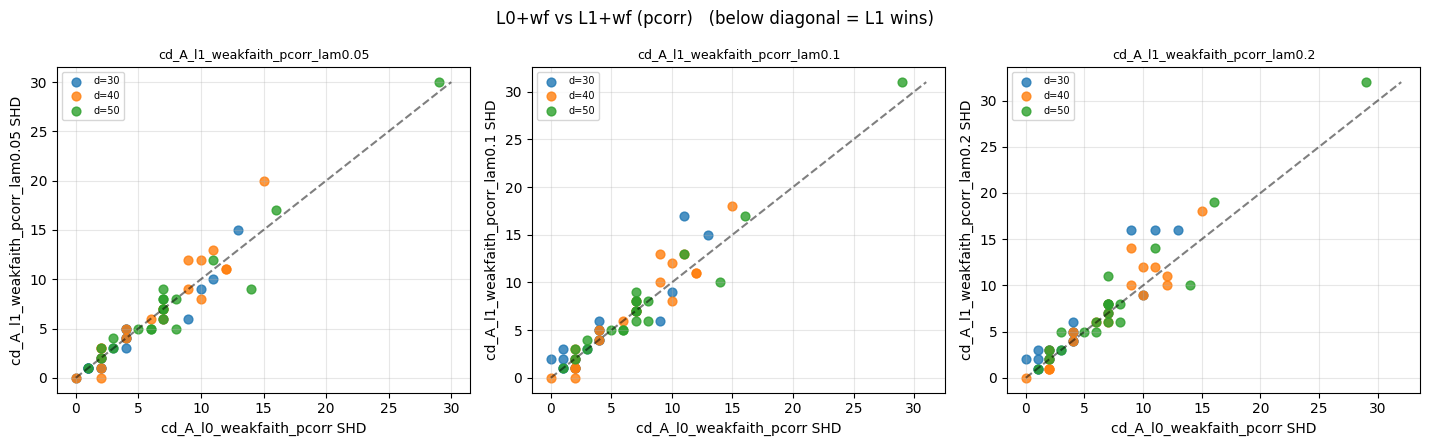

In [9]:
# 8) L0 vs L1 paired scatter (per-trial SHD)
# Pairs each L1 result against its L0 counterpart on the same (d, trial_id, seed).
# Below the diagonal = L1 wins on that trial.
if len(df_trials) == 0:
    print('Run cell 4 first.')
else:
    l1_labels = [v['label'] for v in VARIANTS
                 if v['penalty'] == 'l1' and v.get('faithfulness_tau', 0.0) == 0.0]
    l1_wf_labels = [v['label'] for v in VARIANTS
                    if v['penalty'] == 'l1' and v.get('faithfulness_tau', 0.0) > 0.0]

    pivot_shd = df_trials.pivot_table(
        index=['d', 'n_samples', 'trial_id'], columns='algorithm', values='shd'
    ).reset_index()

    pairs = [
        ('cd_A_l0', l1_labels, 'L0 vs L1 (no screening)'),
        ('cd_A_l0_weakfaith_pcorr', l1_wf_labels, 'L0+wf vs L1+wf (pcorr)'),
    ]

    for ref, others, title in pairs:
        if ref not in pivot_shd.columns or len(others) == 0:
            continue
        fig, axes = plt.subplots(1, len(others), figsize=(4.8 * len(others), 4.5),
                                 squeeze=False)
        for k, l1_lab in enumerate(others):
            ax = axes[0][k]
            if l1_lab not in pivot_shd.columns:
                ax.set_visible(False); continue
            xs = pivot_shd[ref].values
            ys = pivot_shd[l1_lab].values
            ds = pivot_shd['d'].values
            for di, d_val in enumerate(sorted(np.unique(ds))):
                m = ds == d_val
                ax.scatter(xs[m], ys[m], s=40, alpha=0.8,
                           label=f'd={d_val}', color=f'C{di}')
            lo = float(np.nanmin(np.concatenate([xs, ys])))
            hi = float(np.nanmax(np.concatenate([xs, ys])))
            ax.plot([lo, hi], [lo, hi], 'k--', alpha=0.5)
            ax.set_xlabel(f'{ref} SHD')
            ax.set_ylabel(f'{l1_lab} SHD')
            ax.set_title(l1_lab, fontsize=9)
            ax.grid(True, alpha=0.3)
            ax.legend(fontsize=7)
        fig.suptitle(title + '   (below diagonal = L1 wins)', fontsize=12)
        plt.tight_layout()
        plt.show()


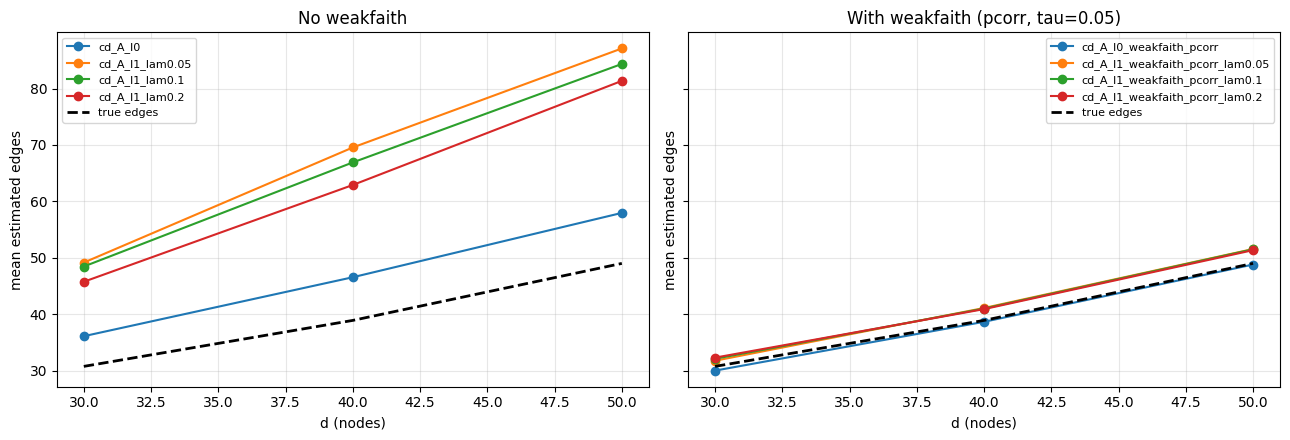

In [10]:
# 9) Edge-count diagnostic: estimated vs true edges
# Useful for spotting whether each (penalty, lambda) over- or under-selects.
if len(df_trials) == 0:
    print('Run cell 4 first.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
    for ax, has_wf, sub_title in [
        (axes[0], 0, 'No weakfaith'),
        (axes[1], 1, 'With weakfaith (pcorr, tau=0.05)'),
    ]:
        sub = df_trials[df_trials['has_wf'] == has_wf]
        if len(sub) == 0:
            ax.set_title(sub_title + ' (no data)')
            continue
        agg = sub.groupby(['d', 'algorithm'])[['n_edges_est', 'n_edges_true']].mean().reset_index()
        for alg in agg['algorithm'].unique():
            v = agg[agg['algorithm'] == alg]
            ax.plot(v['d'], v['n_edges_est'], marker='o', label=alg)
        truth = sub.groupby('d')['n_edges_true'].mean().reset_index()
        ax.plot(truth['d'], truth['n_edges_true'], 'k--', label='true edges', lw=2)
        ax.set_xlabel('d (nodes)')
        ax.set_title(sub_title)
        ax.set_ylabel('mean estimated edges')
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


In [11]:
# 10) Skip log
if skip_logs:
    display(pd.DataFrame(skip_logs))
else:
    print('No skips.')


No skips.
